['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
0       rec.sport.baseball
1          sci.electronics
2       rec.sport.baseball
3       rec.sport.baseball
4          sci.electronics
               ...        
4719          misc.forsale
4720    talk.politics.misc
4721    talk.politics.misc
4722    rec.sport.baseball
4723    rec.sport.baseball
Name: raw_categories, Length: 4724, dtype: str
0          Sport
1           Tech
2          Sport
3          Sport
4           Tech
          ...   
4719    Business
4720    Politics
4721    Politics
4722       Sport
4723       Sport
Name: category, Length: 4724, dtype: str
🎯 BASIC DATASET STATISTICS (FILTER

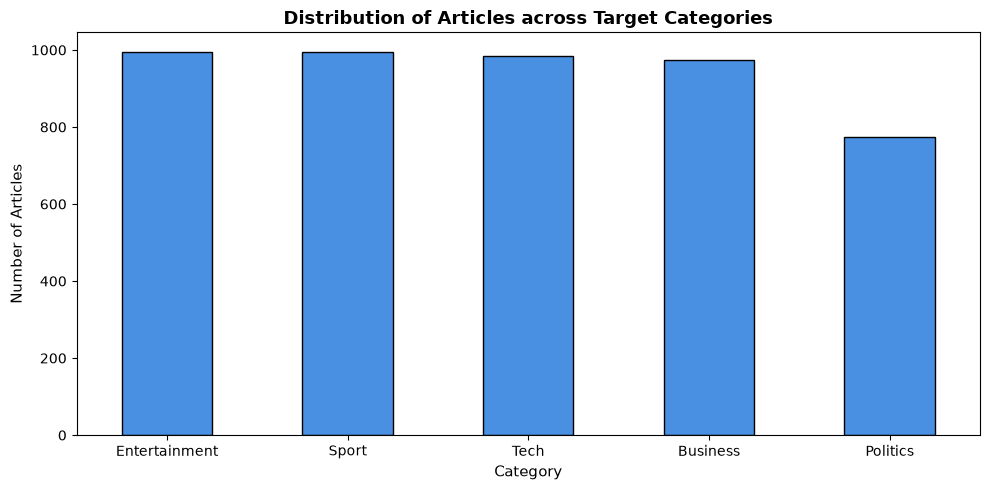

In [28]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# ===============================================================
# PART 1: Data Exploration and Load target Dataset
# ===============================================================
# Common data cleaning parameters
clean_params = {'remove': ('headers', 'footers', 'quotes')}

# Check all categories from 20 Newsgroups
print(fetch_20newsgroups().target_names)

# Mapping the closest technical categories from 20 Newsgroups
category_mapping = {
    'misc.forsale': 'Business',
    'rec.motorcycles': 'Entertainment',
    'talk.politics.misc': 'Politics',
    'rec.sport.baseball': 'Sport',
    'sci.electronics': 'Tech'
}

newsgroups_all = fetch_20newsgroups(subset='all',
                                    **clean_params,
                                    categories=list(category_mapping.keys())
                                    )
# Convert to a Pandas DataFrame for easier analysis
df = pd.DataFrame({
    'text': newsgroups_all.data,
    'raw_categories': [newsgroups_all.target_names[x] for x in newsgroups_all.target],
})

print(df.raw_categories)
# Rename raw technical tags to your clean friendly labels
df['category'] = df['raw_categories'].map(category_mapping)

print(df.category)

# ==========================================
# 2. SHOW BASIC STATISTICS
# ==========================================
print("==========================================")
print("🎯 BASIC DATASET STATISTICS (FILTERED 5 CLASSES)")
print("==========================================")
print(f"Total number of articles: {len(df)}")
print(f"Total unique categories:  {df['category'].nunique()}")

df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print(f"Average words per article: {df['word_count'].mean():.1f}")
print(f"Max words in an article:  {df['word_count'].max()}")
print(f"Min words in an article:  {df['word_count'].min()}\n")

# ==========================================
# 3. DISPLAY A SAMPLE ARTICLE FROM EACH CATEGORY
# ==========================================

print("==========================================")
print("📄 SAMPLE ARTICLES FROM EACH TARGET CATEGORY")
print("==========================================")
for category_name, group in df.groupby('category'):
    # Drop rows that are purely whitespace/empty strings
    valid_articles = group[group['text'].str.strip().str.len() > 0]

    print(f"🏷️ Category: {category_name}")
    print("-" * 40)

    if len(valid_articles) == 0:
        print("[No text content found in samples]")
    else:
        # Pull the first valid post body
        sample_text = valid_articles['text'].iloc[0].strip()
        preview = sample_text[:250].replace('\n', ' ')
        print(f"{preview}...")

    print("=" * 60 + "\n")

# ==========================================
# 4. VISUALIZE ARTICLE DISTRIBUTION BY CATEGORY
# ==========================================

category_count = df['category'].value_counts()
print(category_count)
plt.figure(figsize=(10, 5))
category_count.plot(kind='bar', color='#4A90E2', edgecolor='black')

plt.title('Distribution of Articles across Target Categories', fontsize=13, fontweight='bold')
plt.xlabel('Category', fontsize=11)
plt.ylabel('Number of Articles', fontsize=11)
plt.xticks(rotation=0)  # Keep labels horizontal for readability
plt.tight_layout()
plt.show()

In [46]:
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import time

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# ===============================================================
# PART 1: Data Exploration and Load target Dataset
# ===============================================================
# Common data cleaning parameters
clean_params = {'remove': ('headers', 'footers', 'quotes')}

# Mapping the closest technical categories from 20 Newsgroups
category_mapping = {
    'misc.forsale': 'Business',
    'rec.motorcycles': 'Entertainment',
    'talk.politics.misc': 'Politics',
    'rec.sport.baseball': 'Sport',
    'sci.electronics': 'Tech'
}

newsgroups_all = fetch_20newsgroups(subset='all',
                                    **clean_params,
                                    categories=list(category_mapping.keys())
                                    )
# Convert to a Pandas DataFrame for easier analysis
df = pd.DataFrame({
    'text': newsgroups_all.data,
    'raw_categories': [newsgroups_all.target_names[x] for x in newsgroups_all.target],
})

df['category'] = df['raw_categories'].map(category_mapping)

# ==========================================
# 2. APPLY BASIC PIPELINE
# ==========================================
# Drop any rows that became completely empty after removing headers
df = df[df['text'].str.strip().str.len() > 0].copy()

stop_words = set(stopwords.words('english'))


def process_text(text):
    # print(text)
    text_lower = text.lower()
    tokens = word_tokenize(text_lower)
    clean_tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    # print(clean_tokens)
    # print("*"*100)
    return " ".join(clean_tokens)


print("Processing basic pipeline text column..")
df['clean_text'] = df['text'].apply(process_text)
print("done")

# ==========================================
# 2. APPLY ADVANCED PIPELINE
# ==========================================
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(treebank_tag):
    """Maps POS tags to WordNet compatible tags for precise lemmatization."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None


def preprocess_advance(text):
    text_lower = text.lower()
    tokens = word_tokenize(text_lower)
    pos_tags = pos_tag(tokens)
    advanced_tokens = []
    for word, tag in pos_tags:
        wn_tag = get_wordnet_pos(tag)
        if wn_tag:
            word = lemmatizer.lemmatize(word, pos=wn_tag)
        else:
            word = lemmatizer.lemmatize(word)

        word = stemmer.stem(word)
        advanced_tokens.append(word)
    return " ".join(advanced_tokens)


print("Processing advanced pipeline text column..")
start_time = time.time()
df['clean_advanced'] = df['clean_text'].apply(preprocess_advance)
advanced_time = time.time() - start_time
print(f"✅ Text Processing Complete! and time took {advanced_time} in seconds")

Processing basic pipeline text column..
done
Processing advanced pipeline text column..
✅ Text Processing Complete! and time took 23.50777292251587


⚙️ Vectorizing: Bag of Words...
⚙️ Vectorizing: TF-IDF...
⚙️ Training & Vectorizing: Word2Vec (CBoW)...
⚙️ Training & Vectorizing: Word2Vec (Skip-gram)...

📊 VECTORIZATION BENCHMARK SUMMARY
Method                 | Processing Time (s)  | Output Feature Size
-----------------------------------------------------------------
Bag of Words           | 0.2520               | 1000           
TF-IDF                 | 0.2380               | 1000           
Word2Vec (CBoW)        | 4.7490               | 100            
Word2Vec (Skip-gram)   | 5.8396               | 100            



/var/folders/mk/3k8t72sj69l04zsskj14q1j00000gn/T/ipykernel_60186/2302525148.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(methods, rotation=15)
/var/folders/mk/3k8t72sj69l04zsskj14q1j00000gn/T/ipykernel_60186/2302525148.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(methods, rotation=15)


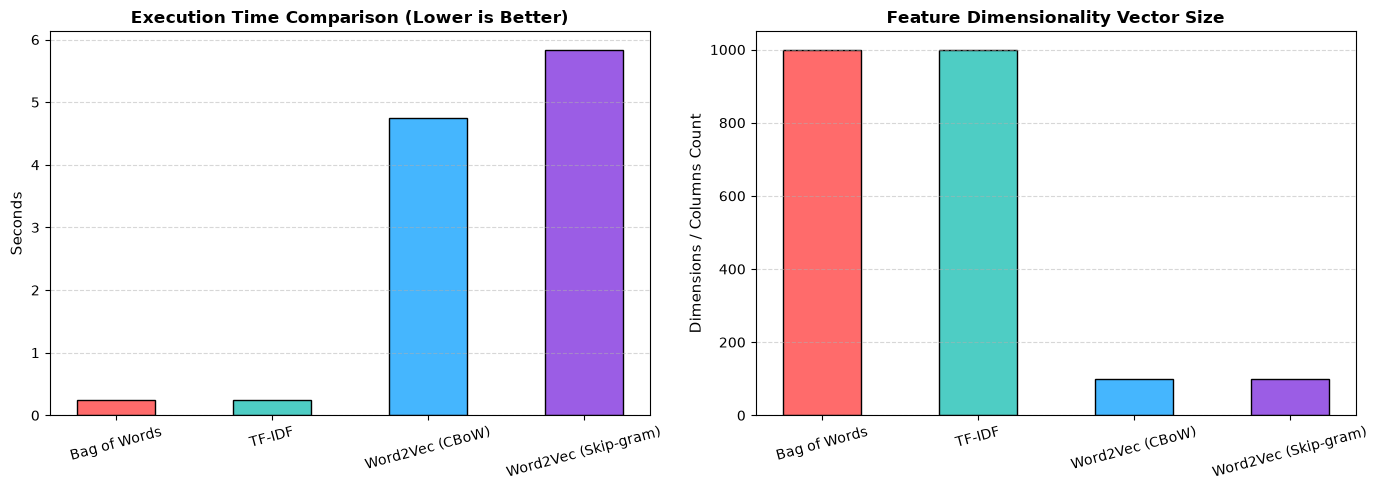

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec
import numpy as np

# ==========================================
# 1. INITIALIZE COUNT VECTORIZER (BAG OF WORDS)
# ==========================================
metrics = {}
# ==========================================
# 2. FEATURE EXTRACTION TECHNIQUES
# ==========================================

# --- 1. Bag of Words (CountVectorizer) ---
print("⚙️ Vectorizing: Bag of Words...")
start = time.time()
bow_vectorizer = CountVectorizer(max_features=1000)
X_bow = bow_vectorizer.fit_transform(df['clean_advanced'])
metrics['Bag of Words'] = {'time': time.time() - start, 'features': X_bow.shape[1]}

# --- 2. TF-IDF (TfidfVectorizer) ---
print("⚙️ Vectorizing: TF-IDF...")
start = time.time()
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_advanced'])
metrics['TF-IDF'] = {'time': time.time() - start, 'features': X_tfidf.shape[1]}


# --- Helper Function for Word2Vec Document Averaging ---
def document_vectorizer(tokens_list, model, vector_size=100):
    """Computes the average word vector for an entire text document."""
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)


# --- 3. Word2Vec: Continuous Bag of Words (CBoW) ---
print("⚙️ Training & Vectorizing: Word2Vec (CBoW)...")
start = time.time()
cbow_model = Word2Vec(sentences=df['clean_advanced'], vector_size=100, window=5, min_count=2, sg=0, workers=4, seed=42)
X_cbow = np.array([document_vectorizer(tokens, cbow_model) for tokens in df['clean_advanced']])
metrics['Word2Vec (CBoW)'] = {'time': time.time() - start, 'features': X_cbow.shape[1]}

# --- 4. Word2Vec: Skip-gram ---
print("⚙️ Training & Vectorizing: Word2Vec (Skip-gram)...")
start = time.time()
sg_model = Word2Vec(sentences=df['clean_advanced'], vector_size=100, window=5, min_count=2, sg=1, workers=4, seed=42)
X_sg = np.array([document_vectorizer(tokens, sg_model) for tokens in df['clean_advanced']])
metrics['Word2Vec (Skip-gram)'] = {'time': time.time() - start, 'features': X_sg.shape[1]}

# ==========================================
# 3. PRINT COMPARISON SUMMARY
# ==========================================
print("\n==========================================================")
print("📊 VECTORIZATION BENCHMARK SUMMARY")
print("==========================================================")
print(f"{'Method':<22} | {'Processing Time (s)':<20} | {'Output Feature Size':<15}")
print("-" * 65)
for method, data in metrics.items():
    print(f"{method:<22} | {data['time']:<20.4f} | {data['features']:<15}")
print("==========================================================\n")

# ==========================================
# 4. PLOT GENERATION (VISUALIZATIONS)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Processing Time Comparison
methods = list(metrics.keys())
times = [metrics[m]['time'] for m in methods]
colors = ['#FF6B6B', '#4ECDC4', '#45B6FE', '#9B5DE5']

ax1.bar(methods, times, color=colors, edgecolor='black', width=0.5)
ax1.set_title('Execution Time Comparison (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Seconds', fontsize=11)
ax1.set_xticklabels(methods, rotation=15)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Output Feature Dimensionality Comparison
feature_sizes = [metrics[m]['features'] for m in methods]
ax2.bar(methods, feature_sizes, color=colors, edgecolor='black', width=0.5)
ax2.set_title('Feature Dimensionality Vector Size', fontsize=12, fontweight='bold')
ax2.set_ylabel('Dimensions / Columns Count', fontsize=11)
ax2.set_xticklabels(methods, rotation=15)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [62]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

# Split into Train and Test splits (80/20)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df['text'].values, df['category'].values, test_size=0.2, random_state=42, stratify=df['category']
)

# Encode target text labels to one-hot arrays
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
y_train = to_categorical(y_train_encoded, num_classes=num_classes)
y_test = to_categorical(y_test_encoded, num_classes=num_classes)

VOCAB_SIZE = 10000        # Maximum number of unique words to keep
MAX_SEQUENCE_LENGTH = 150 # Max number of words per article to pass to LSTM

# The TextVectorization layer automates lowercasing, punctuation removal, and integer encoding
vectorizer_layer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

# Learn the vocabulary from the training text strings
vectorizer_layer.adapt(X_train_raw)

# Transform raw strings to integer sequence vectors
X_train = vectorizer_layer(X_train_raw)
X_test = vectorizer_layer(X_test_raw)

EMBEDDING_DIM = 64  # Size of the dense word vectors

model = Sequential([
    # Input Layer implicitly defined via layer configurations
    # Embedding Layer: turns word integers into dense vectors of shape (batch, sequence_length, dimension)
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),

    # Simple LSTM Layer: processes the sequence word by word
    LSTM(units=64, dropout=0.2, recurrent_dropout=0.2),

    # Dense Output Layer: Softmax outputs class probabilities for our 5 buckets
    Dense(units=num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# TRAIN THE LSTM MODEL
# ==========================================
print("\n🚀 Training the Simple LSTM...")
BATCH_SIZE = 64
EPOCHS = 5

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# ==========================================
# EVALUATE PERFORMANCE
# ==========================================
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("\n==========================================")
print(f"📊 MODEL PERFORMANCE ON TEST SET")
print("==========================================")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss:     {test_loss:.4f}")
print("==========================================")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Training the Simple LSTM...
Epoch 1/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.2264 - loss: 1.5991 - val_accuracy: 0.2478 - val_loss: 1.5881
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.2399 - loss: 1.5820 - val_accuracy: 0.2783 - val_loss: 1.5748
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.3315 - loss: 1.4939 - val_accuracy: 0.3717 - val_loss: 1.4250
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.3701 - loss: 1.4440 - val_accuracy: 0.3804 - val_loss: 1.4098
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.3764 - loss: 1.4335 - val_accuracy: 0.3880 - val_loss: 1.4071

📊 MODEL PERFORMANCE ON TEST SET
Final Test Accuracy: 38.80%
Final Test Loss:     1.4071


In [65]:
import numpy as np
import pandas as pd
import warnings
import sys
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

# ==========================================
# 0. NLTK & DATA SEED SETUP
# ==========================================
np.random.seed(42)
tf.random.set_seed(42)
if not sys.warnoptions:
    warnings.simplefilter("ignore", category=ImportWarning)
    warnings.filterwarnings("ignore", message="Exception ignored in.*our_dot_float")

category_mapping = {
    'misc.forsale': 'Business', 'rec.motorcycles': 'Entertainment',
    'talk.politics.misc': 'Politics', 'rec.sport.baseball': 'Sport',
    'sci.electronics': 'Tech'
}

print("⏳ Loading dataset...")
dataset = fetch_20newsgroups(subset='all', categories=list(category_mapping.keys()), remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({'text': dataset.data, 'target': dataset.target})
df = df[df['text'].str.strip().str.len() > 0].copy()

def clean_and_tokenize(text):
    return [w for w in word_tokenize(text.lower()) if w.isalpha()]

df['tokens'] = df['text'].apply(clean_and_tokenize)
df = df[df['tokens'].str.len() > 0].copy()
df['clean_str'] = df['tokens'].apply(lambda x: " ".join(x))

# Train / Test Split (80/20)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df, df['target'].values, test_size=0.2, random_state=42, stratify=df['target'].values
)

# Convert labels for LSTM
num_classes = 5
y_train_lstm = to_categorical(y_train_raw, num_classes)
y_test_lstm = to_categorical(y_test_raw, num_classes)

# Dictionary to hold results
results = []

def run_logistic_regression(X_tr, X_te, name):
    lr = LogisticRegression(max_iter=500, random_state=42)
    lr.fit(X_tr, y_train_raw)
    preds = lr.predict(X_te)
    acc = accuracy_score(y_test_raw, preds)
    return acc

def run_simple_lstm(X_tr, X_te, name, epochs=3):
    # Determine the structural shape of incoming dimensions
    input_shape = (X_tr.shape[1], X_tr.shape[2])

    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, dropout=0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_tr, y_train_lstm, epochs=epochs, batch_size=64, verbose=0)

    _, acc = model.evaluate(X_te, y_test_lstm, verbose=0)
    return acc

# ==========================================
# 1. BAG OF WORDS & TF-IDF PIPELINES
# ==========================================
print("\n📦 Processing Bag of Words & TF-IDF...")
MAX_FEAT = 500

# BoW
bow_vec = CountVectorizer(max_features=MAX_FEAT)
X_train_bow = bow_vec.fit_transform(X_train_raw['clean_str']).toarray()
X_test_bow = bow_vec.transform(X_test_raw['clean_str']).toarray()

# TF-IDF
tfidf_vec = TfidfVectorizer(max_features=MAX_FEAT)
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw['clean_str']).toarray()
X_test_tfidf = tfidf_vec.transform(X_test_raw['clean_str']).toarray()

# Logistic Regression executions
results.append({'Method': 'Bag of Words', 'Model': 'Logistic Regression', 'Accuracy': run_logistic_regression(X_train_bow, X_test_bow, 'BoW')})
results.append({'Method': 'TF-IDF', 'Model': 'Logistic Regression', 'Accuracy': run_logistic_regression(X_train_tfidf, X_test_tfidf, 'TF-IDF')})

# Reshape BoW & TF-IDF to pseudo-sequences for the LSTM input requirements: (samples, time_steps=1, features)
X_train_bow_seq = np.expand_dims(X_train_bow, axis=1)
X_test_bow_seq = np.expand_dims(X_test_bow, axis=1)
X_train_tfidf_seq = np.expand_dims(X_train_tfidf, axis=1)
X_test_tfidf_seq = np.expand_dims(X_test_tfidf, axis=1)

results.append({'Method': 'Bag of Words', 'Model': 'Simple LSTM', 'Accuracy': run_simple_lstm(X_train_bow_seq, X_test_bow_seq, 'BoW')})
results.append({'Method': 'TF-IDF', 'Model': 'Simple LSTM', 'Accuracy': run_simple_lstm(X_train_tfidf_seq, X_test_tfidf_seq, 'TF-IDF')})

# ==========================================
# 2. WORD2VEC PIPELINES (CBoW & SKIP-GRAM)
# ==========================================
print("🧠 Training Word2Vec embeddings...")
VEC_SIZE = 100
MAX_LEN = 100

cbow_mod = Word2Vec(sentences=X_train_raw['tokens'], vector_size=VEC_SIZE, window=5, min_count=2, sg=0, workers=4, seed=42)
sg_mod = Word2Vec(sentences=X_train_raw['tokens'], vector_size=VEC_SIZE, window=5, min_count=2, sg=1, workers=4, seed=42)

def get_static_avg_vectors(tokens_series, model):
    vectors = []
    for tokens in tokens_series:
        valid_vecs = [model.wv[w] for w in tokens if w in model.wv]
        if valid_vecs:
            vectors.append(np.mean(valid_vecs, axis=0))
        else:
            vectors.append(np.zeros(VEC_SIZE))
    return np.array(vectors)

def get_sequential_vectors(tokens_series, model, max_len=100):
    sequences = []
    for tokens in tokens_series:
        doc_seq = []
        for i in range(max_len):
            if i < len(tokens) and tokens[i] in model.wv:
                doc_seq.append(model.wv[tokens[i]])
            else:
                doc_seq.append(np.zeros(VEC_SIZE)) # Padding
        sequences.append(doc_seq)
    return np.array(sequences)

# Word2Vec Static Averages (for Logistic Regression)
X_train_cbow_avg = get_static_avg_vectors(X_train_raw['tokens'], cbow_mod)
X_test_cbow_avg = get_static_avg_vectors(X_test_raw['tokens'], cbow_mod)
X_train_sg_avg = get_static_avg_vectors(X_train_raw['tokens'], sg_mod)
X_test_sg_avg = get_static_avg_vectors(X_test_raw['tokens'], sg_mod)

results.append({'Method': 'Word2Vec (CBoW)', 'Model': 'Logistic Regression', 'Accuracy': run_logistic_regression(X_train_cbow_avg, X_test_cbow_avg, 'CBoW Avg')})
results.append({'Method': 'Word2Vec (Skip-gram)', 'Model': 'Logistic Regression', 'Accuracy': run_logistic_regression(X_train_sg_avg, X_test_sg_avg, 'SG Avg')})

# Word2Vec Sequential Vectors (for LSTM)
X_train_cbow_seq = get_sequential_vectors(X_train_raw['tokens'], cbow_mod, max_len=MAX_LEN)
X_test_cbow_seq = get_sequential_vectors(X_test_raw['tokens'], cbow_mod, max_len=MAX_LEN)
X_train_sg_seq = get_sequential_vectors(X_train_raw['tokens'], sg_mod, max_len=MAX_LEN)
X_test_sg_seq = get_sequential_vectors(X_test_raw['tokens'], sg_mod, max_len=MAX_LEN)

results.append({'Method': 'Word2Vec (CBoW)', 'Model': 'Simple LSTM', 'Accuracy': run_simple_lstm(X_train_cbow_seq, X_test_cbow_seq, 'CBoW Seq')})
results.append({'Method': 'Word2Vec (Skip-gram)', 'Model': 'Simple LSTM', 'Accuracy': run_simple_lstm(X_train_sg_seq, X_test_sg_seq, 'SG Seq')})

# ==========================================
# 3. DISPLAY FINAL SUMMARY TABLE
# ==========================================
summary_df = pd.DataFrame(results)
print("\n==========================================================")
print("📊 FINAL BENCHMARK PERFORMANCE COMPARISON")
print("==========================================================")
print(summary_df.pivot(index='Method', columns='Model', values='Accuracy').map(lambda x: f"{x*100:.2f}%"))
print("==========================================================")


⏳ Loading dataset...

📦 Processing Bag of Words & TF-IDF...
🧠 Training Word2Vec embeddings...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



📊 FINAL BENCHMARK PERFORMANCE COMPARISON
Model                Logistic Regression Simple LSTM
Method                                              
Bag of Words                      75.19%      75.95%
TF-IDF                            77.69%      75.19%
Word2Vec (CBoW)                   61.70%      45.81%
Word2Vec (Skip-gram)              80.41%      63.66%
